<a href="https://colab.research.google.com/github/ellenyifang2011/sea_level/blob/main/src/replot2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Sea Level Project**

In [2]:
import sys
import sklearn
from packaging import version

print("Welcome to the Ocean!")
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
assert sys.version_info >= (3, 7)

from google.colab import drive
drive.mount('/content/drive')


Welcome to the Ocean!
Mounted at /content/drive


# Get the Data

In [3]:
import os, sys
import pandas as pd

def in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False

def data_dir() -> str:
    if in_colab():
        # default Colab path after mounting Drive
        return "/content/drive/MyDrive/Data"
    return os.path.abspath("./data")  # local default

def path(*parts) -> str:
    return os.path.join(data_dir(), *parts)

def load_data():
    filename="sl_raw2.csv"
    return pd.read_csv(path(filename))

_rawdata = load_data()
_rawdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            244 non-null    float64
 1   Sea Level Monthly Mean          244 non-null    float64
 2   Antarctic Ice Melt Rates(mass)  244 non-null    float64
 3   Greenland Ice Melt Rates(mass)  244 non-null    float64
 4   Global Temp Anomaly             244 non-null    float64
 5   El Nino                         244 non-null    float64
 6   AMOC                            196 non-null    float64
 7   CO2                             244 non-null    float64
dtypes: float64(8)
memory usage: 15.4 KB


In [4]:
import pandas as pd

# Ensure Date exists and is datetime
_rawdata["Date"] = pd.to_datetime(_rawdata["Date"])

# Sort oldest -> newest (critical for time series)
_rawdata = _rawdata.sort_values("Date").reset_index(drop=True)

# Drop AMOC if you want to keep matching your original notebook
#_rawdata = _rawdata.drop(columns=["AMOC"])

# Keep Date for now only if you want to engineer features later;
# we will drop Date right before modeling (in the next cell).
_rawdata.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Date                            244 non-null    datetime64[ns]
 1   Sea Level Monthly Mean          244 non-null    float64       
 2   Antarctic Ice Melt Rates(mass)  244 non-null    float64       
 3   Greenland Ice Melt Rates(mass)  244 non-null    float64       
 4   Global Temp Anomaly             244 non-null    float64       
 5   El Nino                         244 non-null    float64       
 6   AMOC                            196 non-null    float64       
 7   CO2                             244 non-null    float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 15.4 KB



## Create Test Set

In [5]:
# Time-based train/test split: last 20% = test
df = _rawdata.copy()

y = df["Sea Level Monthly Mean"].copy()
X = df.drop(columns=["Sea Level Monthly Mean"])

split = int(len(df) * 0.8)

X_train = X.iloc[:split].copy()
X_test  = X.iloc[split:].copy()
y_train = y.iloc[:split].copy()
y_test  = y.iloc[split:].copy()

# Drop Date from features (we only used it to sort)
X_train = X_train.drop(columns=["Date"])
X_test  = X_test.drop(columns=["Date"])

# Keep your original variable names so later cells still work
rawdata = X_train
rawdata_labels = y_train
testdata = X_test
testdata_labels = y_test

rawdata.info()
testdata.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Antarctic Ice Melt Rates(mass)  195 non-null    float64
 1   Greenland Ice Melt Rates(mass)  195 non-null    float64
 2   Global Temp Anomaly             195 non-null    float64
 3   El Nino                         195 non-null    float64
 4   AMOC                            175 non-null    float64
 5   CO2                             195 non-null    float64
dtypes: float64(6)
memory usage: 9.3 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 195 to 243
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Antarctic Ice Melt Rates(mass)  49 non-null     float64
 1   Greenland Ice Melt Rates(mass)  49 non-null     float64
 2   Global Temp An

## Training and Evaluating on the Training Set

In [6]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

tscv = TimeSeriesSplit(n_splits=5)

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

param_dist = {
    "n_estimators": [400, 800, 1200, 2000, 3000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 6, 8],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(rawdata, rawdata_labels)

print("Best CV RMSE:", -search.best_score_)
print("Best params:", search.best_params_)

model = search.best_estimator_


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV RMSE: 0.06533423562680853
Best params: {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 0.1, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 1.0}


In [7]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np # Import numpy for sqrt

prediction = model.predict(testdata)
# Calculate MSE first, then take the square root for RMSE
mse = mean_squared_error(testdata_labels, prediction)
rmse = np.sqrt(mse)
print("rmse=",rmse)
mae = mean_absolute_error(testdata_labels,prediction)
print("mae=",mae)

rmse= 0.09577613243603063
mae= 0.0772410944128523


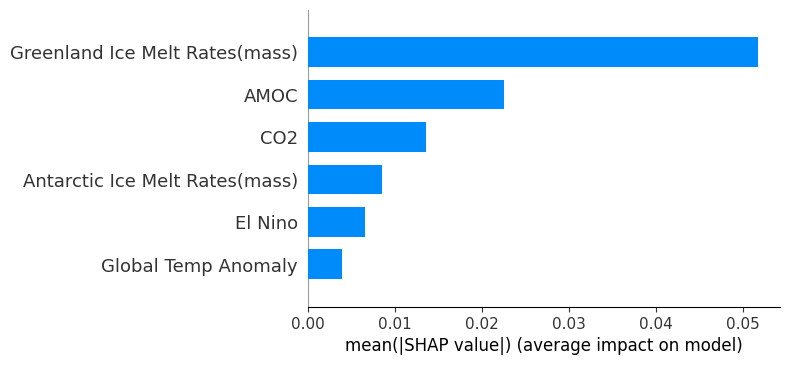

In [8]:
# If you haven't installed shap yet (run once):
# !pip -q install shap

import shap
import numpy as np
import matplotlib.pyplot as plt

# SHAP works best with DataFrames (keeps feature names)
X_train_shap = rawdata.copy()
X_test_shap  = testdata.copy()

# For XGBoost tree models:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_shap)

# 1) Global importance summary (beeswarm)
#shap.summary_plot(shap_values, X_test_shap, show=False)
#plt.tight_layout()
#plt.show()

plt.figure(figsize=(10, 6))  # make figure wider

shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar",
    show=False
)

plt.xlabel("mean(|SHAP value|) (average impact on model)", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # add space for long x-axis label
plt.show()

# 3) One example explanation (waterfall)
#i = 0  # change to any row index you want
#sv = shap.Explanation(
#    values=shap_values[i],
#    base_values=explainer.expected_value,
#    data=X_test_shap.iloc[i],
#    feature_names=X_test_shap.columns
#)
#shap.plots.waterfall(sv)


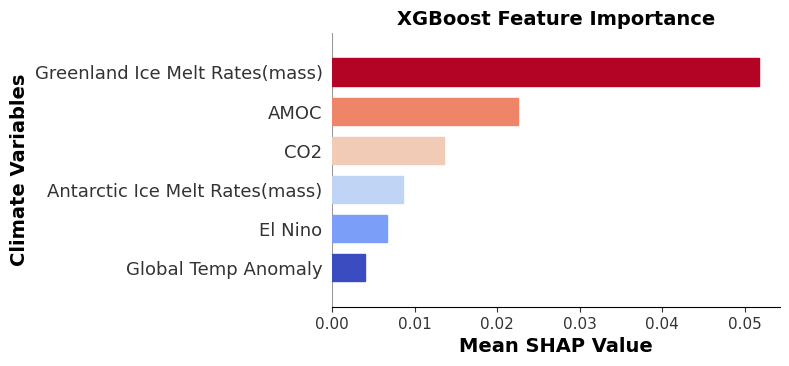

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0')])

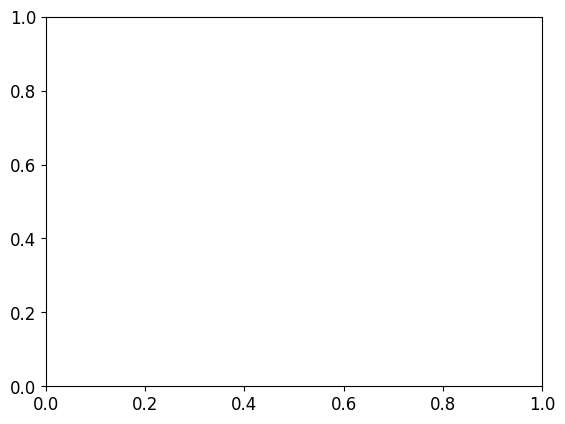

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
top_n=6

plt.figure(figsize=(10, 6))  # make figure wider

shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar",
    show=False,
)

# Get bars and recolor them
bars = plt.gca().patches

colors = plt.cm.coolwarm(np.linspace(0, 1, top_n))

for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.xlabel("Mean SHAP Value", fontsize=14, fontweight='bold')
plt.ylabel("Climate Variables", fontsize=14, fontweight='bold')
plt.title("XGBoost Feature Importance", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # add space for long x-axis label
plt.show()

# Optional: control tick label size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)



